# Who Pollutes, Who Pays?
## Data Preprocessing & Integration Notebook

**Central question:** Do wealthier nations systematically emit more GHG per capita? And are low-emission countries 'green by choice' or 'green by poverty'?

**Datasets:**
1. `OECD GHG Emissions`: GHG per capita (kg CO₂-eq/person), 99 countries, 1988–2023  
2. `World Bank Economy & Growth`: GDP per capita (PPP, current intl $), 265 countries, 1960–2020  
3. `World Bank Energy & Mining`: Renewable energy share (%), electricity access (%), 265 countries, 1960–2020  

**Join key:** ISO-3 country code  
**Analysis window:** 2014–2020 (overlap of all three datasets)

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Raw Datasets

In [2]:
# OECD GHG Emissions 
GHG_PATH = 'data/OECD.csv'

ghg_raw = pd.read_csv(GHG_PATH)
print(f'GHG raw shape: {ghg_raw.shape}')
print(f'Columns: {ghg_raw.columns.tolist()}')
ghg_raw.head(3)

GHG raw shape: (2723, 30)
Columns: ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA', 'Reference area', 'FREQ', 'Frequency of observation', 'POLLUTANT', 'Pollutant', 'MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure', 'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value', 'OBS_STATUS', 'Observation status', 'UNIT_MULT', 'Unit multiplier', 'PRICE_BASE', 'Price base', 'BASE_PER', 'Base period', 'DECIMALS', 'Decimals', 'CONVERSION_TYPE', 'Conversion type']


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,POLLUTANT,Pollutant,MEASURE,Measure,UNIT_MEASURE,Unit of measure,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,PRICE_BASE,Price base,BASE_PER,Base period,DECIMALS,Decimals,CONVERSION_TYPE,Conversion type
0,DATAFLOW,OECD.ENV.EPI:DSD_AIR_GHG@DF_AIR_GHG(1.0),Air emissions - Greenhouse gas emissions Inven...,I,AUS,Australia,A,Annual,GHG,Greenhouse gases,_T,Total emissions excluding LULUCF,KG_CO2E_PS,Kilogrammes of CO2-equivalent per person,2023,NaN,19.93,NaN,A,Normal value,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN
1,DATAFLOW,OECD.ENV.EPI:DSD_AIR_GHG@DF_AIR_GHG(1.0),Air emissions - Greenhouse gas emissions Inven...,I,AUT,Austria,A,Annual,GHG,Greenhouse gases,_T,Total emissions excluding LULUCF,KG_CO2E_PS,Kilogrammes of CO2-equivalent per person,2023,NaN,7.52,NaN,A,Normal value,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN
2,DATAFLOW,OECD.ENV.EPI:DSD_AIR_GHG@DF_AIR_GHG(1.0),Air emissions - Greenhouse gas emissions Inven...,I,BEL,Belgium,A,Annual,GHG,Greenhouse gases,_T,Total emissions excluding LULUCF,KG_CO2E_PS,Kilogrammes of CO2-equivalent per person,2023,NaN,8.39,NaN,A,Normal value,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN


In [3]:
# World Bank Economy & Growth
eco_raw = pd.read_csv('data/economy-and-growth.csv')
print(f'Economy raw shape: {eco_raw.shape}')
print(f'Year range: {eco_raw["Year"].min()} – {eco_raw["Year"].max()}')
eco_raw.head(3)

Economy raw shape: (15585, 53)
Year range: 1960 – 2020


,Country Name,Country Code,Year,average_value_DEC alternative conversion factor (LCU per US$),average_value_Discrepancy in expenditure estimate of GDP (current LCU),average_value_GDP (constant 2010 US$),average_value_GDP (constant LCU),average_value_GDP (current LCU),average_value_GDP (current US$),average_value_GDP deflator (base year varies by country),average_value_GDP growth (annual %),average_value_GDP per capita (constant 2010 US$),average_value_GDP per capita (constant LCU),average_value_GDP per capita (current LCU),average_value_GDP per capita (current US$),...,average_value_Gross savings (current LCU),average_value_Gross savings (current US$),average_value_Gross value added at basic prices (GVA) (constant LCU),average_value_Gross value added at basic prices (GVA) (current LCU),average_value_Gross value added at basic prices (GVA) (current US$),average_value_Net primary income (Net income from abroad) (current LCU),average_value_Net primary income (Net income from abroad) (current US$),average_value_Net secondary income (Net current transfers from abroad) (current LCU),average_value_Net secondary income (Net current transfers from abroad) (current US$),"average_value_PPP conversion factor, GDP (LCU per international $)","average_value_PPP conversion factor, private consumption (LCU per international $)",average_value_Price level ratio of PPP conversion factor (GDP) to market exchange rate,average_value_Taxes less subsidies on products (constant LCU),average_value_Taxes less subsidies on products (current LCU),average_value_Taxes less subsidies on products (current US$)
0,Arab World,ARB,1988,NaN,NaN,822211133754.53,NaN,NaN,421921035099.97,NaN,5.65,3936.10,NaN,NaN,2019.83,...,NaN,NaN,NaN,NaN,449861580220.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,United Arab Emirates,ARE,1966,4.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Antigua and Barbuda,ATG,1962,1.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# World Bank Energy & Mining 
nrg_raw = pd.read_csv('data/energy-and-mining.csv')
print(f'Energy raw shape: {nrg_raw.shape}')
print(f'Year range: {nrg_raw["Year"].min()} – {nrg_raw["Year"].max()}')
nrg_raw.head(3)

Energy raw shape: (15535, 53)
Year range: 1960 – 2020


,Country Name,Country Code,Year,average_value_Access to electricity (% of population),"average_value_Access to electricity, rural (% of rural population)","average_value_Access to electricity, urban (% of urban population)",average_value_Adjusted savings: energy depletion (% of GNI),average_value_Adjusted savings: energy depletion (current US$),average_value_Adjusted savings: mineral depletion (% of GNI),average_value_Adjusted savings: mineral depletion (current US$),average_value_Adjusted savings: natural resources depletion (% of GNI),average_value_Alternative and nuclear energy (% of total energy use),average_value_CO2 emissions from gaseous fuel consumption (% of total),average_value_CO2 emissions from liquid fuel consumption (kt),average_value_Combustible renewables and waste (% of total energy),...,average_value_Mineral rents (% of GDP),average_value_Natural gas rents (% of GDP),average_value_Nitrous oxide emissions in energy sector (% of total),average_value_Nitrous oxide emissions in energy sector (thousand metric tons of CO2 equivalent),average_value_Oil rents (% of GDP),average_value_Ores and metals exports (% of merchandise exports),average_value_Ores and metals imports (% of merchandise imports),average_value_Pump price for diesel fuel (US$ per liter),average_value_Pump price for gasoline (US$ per liter),average_value_Renewable electricity output (% of total electricity output),average_value_Renewable energy consumption (% of total final energy consumption),average_value_Time required to get electricity (days),average_value_Time to obtain an electrical connection (days),average_value_Total natural resources rents (% of GDP),average_value_Value lost due to electrical outages (% of sales for affected firms)
0,Africa Eastern and Southern,AFE,1987,NaN,NaN,NaN,1.34,NaN,1.32,NaN,4.12,2.11,0.08,73479.52,44.94,...,2.41,0.00,2.16,5762.79,0.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.03,NaN
1,Albania,ALB,2019,100.00,100.00,100.00,0.83,124687724.86,0.01,1783616.76,0.87,NaN,NaN,NaN,NaN,...,0.03,0.02,NaN,NaN,1.35,NaN,NaN,NaN,NaN,NaN,NaN,71.00,18.60,1.59,1.90
2,Albania,ALB,1977,NaN,NaN,NaN,NaN,70677019.42,NaN,6867636.58,NaN,8.15,12.24,2948.27,16.15,...,NaN,NaN,3.71,37.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Clean OECD GHG Dataset

**Key choices:**
- Keep only `MEASURE == '_T'` (total emissions excl. LULUCF) and `UNIT_MEASURE == 'KG_CO2E_PS'` (kg CO₂-eq per person)
- Drop aggregate/supranational entities (EU27, OECD, etc.) --> they are not countries
- Rename columns to clean, short names
- Filter to 2014–2023 (the decade of interest)

In [5]:
# Supranational aggregates to exclude
AGGREGATES = {'EU27_2020', 'OECD', 'OECDA', 'OECDSO', 'OECDE'}

ghg = (
    ghg_raw
    # Keep only the per-capita total GHG measure
    .query("MEASURE == '_T' and UNIT_MEASURE == 'KG_CO2E_PS'")
    # Drop supranational aggregates
    .loc[lambda df: ~df['REF_AREA'].isin(AGGREGATES)]
    # Select and rename relevant columns
    [['REF_AREA', 'Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
    .rename(columns={
        'REF_AREA': 'iso3',
        'Reference area': 'country_name_ghg',
        'TIME_PERIOD': 'year',
        'OBS_VALUE': 'ghg_per_capita'
    })
    # Filter to 2014–2023
    .query('year >= 2014 and year <= 2023')
    .dropna(subset=['ghg_per_capita'])
    .reset_index(drop=True)
)

print(f'GHG cleaned shape: {ghg.shape}')
print(f'Countries: {ghg["iso3"].nunique()}')
print(f'Years: {sorted(ghg["year"].unique())}')
ghg.head()

GHG cleaned shape: (789, 4)
Countries: 90
Years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


,iso3,country_name_ghg,year,ghg_per_capita
0,AUS,Australia,2023,19.93
1,AUT,Austria,2023,7.52
2,BEL,Belgium,2023,8.39
3,CAN,Canada,2023,17.66
4,CZE,Czechia,2023,9.44


In [6]:
# Quick check: missing values
print('GHG missing values:')
print(ghg.isnull().sum())

# Summary stats
print('\nGHG per capita descriptive stats:')
print(ghg['ghg_per_capita'].describe())

GHG missing values:
iso3                0
country_name_ghg    0
year                0
ghg_per_capita      0
dtype: int64

GHG per capita descriptive stats:
count   789.00
mean      7.99
std       5.66
min       0.69
25%       4.49
50%       6.67
75%       9.79
max      33.77
Name: ghg_per_capita, dtype: float64


## 3. Clean World Bank Economy Dataset

**Key variable selected:** `GDP per capita, PPP (current international $)` —-> chosen over nominal GDP/capita because PPP adjusts for price-level differences, making cross-country comparisons more meaningful for living-standard analysis.

**Key choices:**
- Filter to 2014–2020 (overlap window)
- Drop World Bank regional/income-group aggregates (they share no ISO-3 code with GHG countries)
- Keep only rows with non-missing GDP per capita PPP

In [7]:
GDP_COL = 'average_value_GDP per capita, PPP (current international $)'

eco = (
    eco_raw
    [['Country Name', 'Country Code', 'Year', GDP_COL]]
    .rename(columns={
        'Country Name': 'country_name_wb',
        'Country Code': 'iso3',
        'Year': 'year',
        GDP_COL: 'gdp_per_capita_ppp'
    })
    .query('year >= 2014 and year <= 2020')
    .dropna(subset=['gdp_per_capita_ppp'])
    .reset_index(drop=True)
)

print(f'Economy cleaned shape: {eco.shape}')
print(f'Countries: {eco["iso3"].nunique()}')
print(f'Years: {sorted(eco["year"].unique())}')
eco.head()

Economy cleaned shape: (1676, 4)
Countries: 243
Years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


,country_name_wb,iso3,year,gdp_per_capita_ppp
0,Belgium,BEL,2018,52662.53
1,Canada,CAN,2017,48317.10
2,"Egypt, Arab Rep.",EGY,2019,12260.72
3,Guinea-Bissau,GNB,2019,2021.30
4,"Hong Kong SAR, China",HKG,2016,57221.41


In [8]:
print('Economy missing values after filter:')
print(eco.isnull().sum())
print('\nGDP per capita PPP stats:')
print(eco['gdp_per_capita_ppp'].describe())

Economy missing values after filter:
country_name_wb       0
iso3                  0
year                  0
gdp_per_capita_ppp    0
dtype: int64

GDP per capita PPP stats:
count     1676.00
mean     20012.11
std      20811.24
min        720.32
25%       4683.49
50%      13064.42
75%      27865.26
max     152856.34
Name: gdp_per_capita_ppp, dtype: float64


## 4. Clean World Bank Energy Dataset

**Key variables selected:**
- `Renewable energy consumption (% of total final energy consumption)` —-> proxy for clean energy transition
- `Access to electricity (% of population)` —-> proxy for energy poverty
- `Fossil fuel energy consumption (% of total)` —-> complementary to renewable share

Same temporal filter: 2014–2020.

In [9]:
RENEW_COL   = 'average_value_Renewable energy consumption (% of total final energy consumption)'
ELEC_COL    = 'average_value_Access to electricity (% of population)'
FOSSIL_COL  = 'average_value_Fossil fuel energy consumption (% of total)'

nrg = (
    nrg_raw
    [['Country Name', 'Country Code', 'Year', RENEW_COL, ELEC_COL, FOSSIL_COL]]
    .rename(columns={
        'Country Name': 'country_name_wb',
        'Country Code': 'iso3',
        'Year': 'year',
        RENEW_COL:  'renewable_pct',
        ELEC_COL:   'electricity_access_pct',
        FOSSIL_COL: 'fossil_fuel_pct'
    })
    .query('year >= 2014 and year <= 2020')
    .reset_index(drop=True)
)

print(f'Energy cleaned shape: {nrg.shape}')
print(f'Countries: {nrg["iso3"].nunique()}')
nrg.head()

Energy cleaned shape: (1707, 6)
Countries: 265


,country_name_wb,iso3,year,renewable_pct,electricity_access_pct,fossil_fuel_pct
0,Albania,ALB,2019,NaN,100.00,NaN
1,Armenia,ARM,2020,NaN,NaN,NaN
2,Azerbaijan,AZE,2015,2.31,100.00,NaN
3,China,CHN,2014,12.06,100.00,87.67
4,Isle of Man,IMN,2017,1.88,100.00,NaN


In [10]:
print('Energy missing values (per column):')
print(nrg.isnull().sum())
print()

# How many country-year pairs have at least one energy variable?
nrg_any = nrg.dropna(subset=['renewable_pct', 'electricity_access_pct', 'fossil_fuel_pct'], how='all')
print(f'Country-year pairs with ≥1 energy value: {len(nrg_any)}')

Energy missing values (per column):
country_name_wb              0
iso3                         0
year                         0
renewable_pct              546
electricity_access_pct     123
fossil_fuel_pct           1467
dtype: int64

Country-year pairs with ≥1 energy value: 1589


## 5. Add World Bank Region / Continent Metadata

The `continent` / macro-region variable is **not present in any raw dataset** and must be constructed externally.

We use the World Bank's official 7-region classification, embedded here as a static mapping to avoid any external API dependency. The mapping covers all ISO-3 codes present in the GHG dataset.

In [11]:
# World Bank 7-region classification (manually curated for GHG countries)
# Source: https://datahelpdesk.worldbank.org/knowledgebase/articles/906519
WB_REGION = {
    # Europe & Central Asia
    'AUT': 'Europe & Central Asia', 'BEL': 'Europe & Central Asia',
    'CZE': 'Europe & Central Asia', 'DNK': 'Europe & Central Asia',
    'EST': 'Europe & Central Asia', 'FIN': 'Europe & Central Asia',
    'FRA': 'Europe & Central Asia', 'DEU': 'Europe & Central Asia',
    'GRC': 'Europe & Central Asia', 'HUN': 'Europe & Central Asia',
    'ISL': 'Europe & Central Asia', 'IRL': 'Europe & Central Asia',
    'ITA': 'Europe & Central Asia', 'LVA': 'Europe & Central Asia',
    'LTU': 'Europe & Central Asia', 'LUX': 'Europe & Central Asia',
    'NLD': 'Europe & Central Asia', 'NOR': 'Europe & Central Asia',
    'POL': 'Europe & Central Asia', 'PRT': 'Europe & Central Asia',
    'SVK': 'Europe & Central Asia', 'SVN': 'Europe & Central Asia',
    'ESP': 'Europe & Central Asia', 'SWE': 'Europe & Central Asia',
    'CHE': 'Europe & Central Asia', 'GBR': 'Europe & Central Asia',
    'AZE': 'Europe & Central Asia', 'BLR': 'Europe & Central Asia',
    'TUR': 'Europe & Central Asia',
    # North America
    'CAN': 'North America', 'MEX': 'North America', 'USA': 'North America',
    # Latin America & Caribbean
    'ARG': 'Latin America & Caribbean', 'BRB': 'Latin America & Caribbean',
    'CHL': 'Latin America & Caribbean', 'COL': 'Latin America & Caribbean',
    'CRI': 'Latin America & Caribbean',
    # East Asia & Pacific
    'AUS': 'East Asia & Pacific', 'JPN': 'East Asia & Pacific',
    'KOR': 'East Asia & Pacific', 'NZL': 'East Asia & Pacific',
    'BTN': 'East Asia & Pacific',
    # South Asia
    # (none in GHG sample)
    # Middle East & North Africa
    'ISR': 'Middle East & North Africa', 'DZA': 'Middle East & North Africa',
}

# Add missing countries to the World Bank region mapping
WB_REGION.update({
    # Europe & Central Asia
    'BGR': 'Europe & Central Asia',
    'HRV': 'Europe & Central Asia',
    'CYP': 'Europe & Central Asia',
    'GEO': 'Europe & Central Asia',
    'KAZ': 'Europe & Central Asia',
    'LIE': 'Europe & Central Asia',
    'MLT': 'Europe & Central Asia',
    'MDA': 'Europe & Central Asia',
    'MCO': 'Europe & Central Asia',
    'ROU': 'Europe & Central Asia',
    'RUS': 'Europe & Central Asia',
    'SRB': 'Europe & Central Asia',
    'UKR': 'Europe & Central Asia',
    'UZB': 'Europe & Central Asia',

    # Latin America & Caribbean
    'BRA': 'Latin America & Caribbean',
    'CUB': 'Latin America & Caribbean',
    'GTM': 'Latin America & Caribbean',
    'GUY': 'Latin America & Caribbean',
    'PAN': 'Latin America & Caribbean',
    'PER': 'Latin America & Caribbean',
    'URY': 'Latin America & Caribbean',
    'VEN': 'Latin America & Caribbean',

    # East Asia & Pacific
    'BRN': 'East Asia & Pacific',
    'CHN': 'East Asia & Pacific',
    'IDN': 'East Asia & Pacific',
    'MYS': 'East Asia & Pacific',
    'SGP': 'East Asia & Pacific',
    'SLB': 'East Asia & Pacific',
    'THA': 'East Asia & Pacific',

    # South Asia
    'IND': 'South Asia',
    'MDV': 'South Asia',
    'NPL': 'South Asia',

    # Middle East & North Africa
    'EGY': 'Middle East & North Africa',
    'IRQ': 'Middle East & North Africa',
    'LBN': 'Middle East & North Africa',
    'MAR': 'Middle East & North Africa',
    'SAU': 'Middle East & North Africa',

    # Sub-Saharan Africa
    'CIV': 'Sub-Saharan Africa',
    'GHA': 'Sub-Saharan Africa',
    'GNB': 'Sub-Saharan Africa',
    'KEN': 'Sub-Saharan Africa',
    'MUS': 'Sub-Saharan Africa',
    'NAM': 'Sub-Saharan Africa',
    'NGA': 'Sub-Saharan Africa',
    'RWA': 'Sub-Saharan Africa',
    'ZAF': 'Sub-Saharan Africa',

    # Special small state
    'VAT': 'Europe & Central Asia'
})

# Verify coverage
ghg_countries = set(ghg['iso3'].unique())
mapped = set(WB_REGION.keys())
unmapped = ghg_countries - mapped
print(f'GHG countries: {len(ghg_countries)}')
print(f'Mapped to region: {len(mapped & ghg_countries)}')
print(f'Unmapped (will be NaN): {unmapped}')

GHG countries: 90
Mapped to region: 90
Unmapped (will be NaN): set()


In [12]:
ghg['region'] = ghg['iso3'].map(WB_REGION)

print('Region distribution in GHG dataset:')
print(ghg.groupby('region')['iso3'].nunique().sort_values(ascending=False))

Region distribution in GHG dataset:
region
Europe & Central Asia         44
East Asia & Pacific           12
Latin America & Caribbean     12
Sub-Saharan Africa             9
Middle East & North Africa     7
North America                  3
South Asia                     3
Name: iso3, dtype: int64


## 6. Three-Way Join

**Strategy:**
- **Anchor:** GHG dataset (has country-year rows for 2014–2023)
- **Left join** Economy on `(iso3, year)` —-> keeps all GHG rows, adds GDP where available
- **Left join** Energy on `(iso3, year)` —-> keeps all GHG rows, adds energy vars where available
- Time window restricted to **2014–2020** for the complete 3-dataset panel
- A separate **2014–2023 GHG-only** dataframe is kept for trend visualizations

In [13]:
# 6a. Full trend dataset (GHG only, 2014–2023) 
df_trend = ghg.copy()
print(f'Trend dataset (GHG only 2014-2023): {df_trend.shape}')

# 6b. Joined panel (2014–2020) 
ghg_2020 = ghg.query('year <= 2020').copy()

# Join economy
df = ghg_2020.merge(
    eco[['iso3', 'year', 'gdp_per_capita_ppp']],
    on=['iso3', 'year'],
    how='left'
)

# Join energy
df = df.merge(
    nrg[['iso3', 'year', 'renewable_pct', 'electricity_access_pct', 'fossil_fuel_pct']],
    on=['iso3', 'year'],
    how='left'
)

print(f'\nJoined panel shape (2014-2020): {df.shape}')
print(f'Countries with GHG data: {df["iso3"].nunique()}')
df.head()

Trend dataset (GHG only 2014-2023): (789, 5)

Joined panel shape (2014-2020): (575, 9)
Countries with GHG data: 90


,iso3,country_name_ghg,year,ghg_per_capita,region,gdp_per_capita_ppp,renewable_pct,electricity_access_pct,fossil_fuel_pct
0,AUS,Australia,2017,22.75,East Asia & Pacific,48482.65,9.69,100.00,NaN
1,AUT,Austria,2017,9.39,Europe & Central Asia,54169.96,33.96,100.00,NaN
2,BEL,Belgium,2017,10.25,Europe & Central Asia,50442.27,9.64,100.00,NaN
3,CAN,Canada,2017,20.04,North America,48317.10,22.77,100.00,NaN
4,CHL,Chile,2017,5.70,Latin America & Caribbean,24470.70,24.11,99.70,NaN


In [14]:
# Missing value audit on the joined panel
print('Missing values in joined panel:')
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
audit = pd.DataFrame({'missing_n': miss, 'missing_%': miss_pct})
print(audit[audit['missing_n'] > 0])

Missing values in joined panel:
                        missing_n  missing_%
gdp_per_capita_ppp             36       6.30
renewable_pct                 181      31.50
electricity_access_pct         95      16.50
fossil_fuel_pct               470      81.70


In [15]:
# Countries with ALL THREE variables for at least one year in 2014-2020
complete_mask = df[['ghg_per_capita', 'gdp_per_capita_ppp', 'renewable_pct', 'electricity_access_pct']].notna().all(axis=1)
complete_countries = df.loc[complete_mask, 'iso3'].nunique()
print(f'Countries with complete data (all 4 key vars) in ≥1 year: {complete_countries}')

# Country-year pairs fully complete
print(f'Fully complete country-year pairs: {complete_mask.sum()}')

Countries with complete data (all 4 key vars) in ≥1 year: 77
Fully complete country-year pairs: 379


## 7. Analytical Sample Definition

We define the **core analytical sample** as countries with data on all four key variables for **at least 5 of the 7 years** in the **2014–2020** window.

This is a **coverage-based compromise**: requiring all 7 years would shrink the sample too much, while allowing just 1 complete year would weaken comparability across visualizations. The `>=5` rule keeps a broad country set while still preserving reasonably stable multi-year coverage.

Countries with partial data are retained in `df` for single-dataset visualizations (for example, the GHG-only trend chart), but results from `df_core` should be described as applying to a **partially balanced panel**, not a fully complete one.

In [16]:
KEY_VARS = ['ghg_per_capita', 'gdp_per_capita_ppp', 'renewable_pct', 'electricity_access_pct']

# Core sample: countries with complete data in ALL years 2014-2020
country_completeness = (
    df.groupby('iso3')[KEY_VARS]
    .apply(lambda g: g.notna().all(axis=1).sum())
    .reset_index()
    .rename(columns={0: 'complete_years'})
)

# Keep countries with data for at least 5 of the 7 years
core_countries = country_completeness.loc[
    country_completeness['complete_years'] >= 5, 'iso3'
].tolist()

print(f'Core analytical sample (≥5 complete years): {len(core_countries)} countries')

df_core = df[df['iso3'].isin(core_countries)].copy()
print(f'Core panel shape: {df_core.shape}')

Core analytical sample (≥5 complete years): 75 countries
Core panel shape: (525, 9)


In [17]:
# Region distribution in core sample
core_regions = df_core.drop_duplicates('iso3')[['iso3', 'region']]
print('Core sample by region:')
print(core_regions['region'].value_counts())

Core sample by region:
region
Europe & Central Asia         40
East Asia & Pacific            9
Latin America & Caribbean      9
Sub-Saharan Africa             9
North America                  3
Middle East & North Africa     3
South Asia                     2
Name: count, dtype: int64


## 8. Derived Variables

We compute additional variables needed by specific visualizations:

- **`ghg_change_pct`**: % change in GHG per capita from 2014 to 2023 (for slope chart / trend viz, uses `df_trend`)
- **`log_gdp`**: log₁₀ of GDP per capita PPP (linearizes the wealth–emissions scatter)
- **`energy_poverty_flag`**: binary flag —-> country has low electricity access (<85%) AND low GHG per capita (< global median)
- **`green_by_choice_flag`**: binary flag based on low GHG (<median) AND high renewables (>median)

In [18]:
# 8a. GHG trend change 2014→2023 
ghg_2014 = df_trend[df_trend['year'] == 2014][['iso3', 'ghg_per_capita']].rename(columns={'ghg_per_capita': 'ghg_2014'})
ghg_2023 = df_trend[df_trend['year'] == 2023][['iso3', 'ghg_per_capita']].rename(columns={'ghg_per_capita': 'ghg_2023'})

# Keep only countries observed in both endpoint years
df_slope = ghg_2014.merge(ghg_2023, on='iso3', how='inner')
df_slope['ghg_change_pct'] = ((df_slope['ghg_2023'] - df_slope['ghg_2014']) / df_slope['ghg_2014'] * 100).round(2)
df_slope['ghg_change_abs'] = (df_slope['ghg_2023'] - df_slope['ghg_2014']).round(3)

# Add country name and region
meta = ghg[['iso3', 'country_name_ghg', 'region']].drop_duplicates('iso3')
df_slope = df_slope.merge(meta, on='iso3', how='left')

print(f'Slope chart dataset: {df_slope.shape}')
print('\nTop 5 improvers (% reduction):')
print(df_slope.nsmallest(5, 'ghg_change_pct')[['iso3','country_name_ghg','ghg_2014','ghg_2023','ghg_change_pct']])
print('\nTop 5 worseners (% increase):')
print(df_slope.nlargest(5, 'ghg_change_pct')[['iso3','country_name_ghg','ghg_2014','ghg_2023','ghg_change_pct']])

Slope chart dataset: (44, 7)

Top 5 improvers (% reduction):
   iso3 country_name_ghg  ghg_2014  ghg_2023  ghg_change_pct
6   EST          Estonia     15.97      7.95          -50.24
19  LUX       Luxembourg     19.43     11.68          -39.89
38  MLT            Malta      6.55      4.21          -35.66
39  MCO           Monaco      2.35      1.53          -34.60
7   FIN          Finland     10.73      7.33          -31.68

Top 5 worseners (% increase):
   iso3 country_name_ghg  ghg_2014  ghg_2023  ghg_change_pct
42  SRB           Serbia      7.62      9.17           20.37
30  TUR          Türkiye      6.00      6.86           14.43
34  HRV          Croatia      5.76      6.52           13.30
41  RUS           Russia     13.66     14.32            4.84
17  LVA           Latvia      5.37      5.30           -1.44


In [19]:
# 8b. Log GDP & classification flags 
df_core['log_gdp'] = np.log10(df_core['gdp_per_capita_ppp'].replace(0, np.nan))

# Use 2018 as reference year for thresholds (midpoint of 2014-2020, good coverage)
ref = df_core[df_core['year'] == 2018].copy()
ghg_median  = ref['ghg_per_capita'].median()
renew_median = ref['renewable_pct'].median()
elec_threshold = 85  # WHO/World Bank standard for meaningful electricity access

print(f'2018 reference thresholds:')
print(f'  GHG per capita median:    {ghg_median:.1f} kg CO₂-eq/person')
print(f'  Renewable share median:   {renew_median:.1f}%')
print(f'  Electricity access threshold: {elec_threshold}%')

df_core['energy_poverty_flag'] = (
    (df_core['electricity_access_pct'] < elec_threshold) &
    (df_core['ghg_per_capita'] < ghg_median)
).astype(int)

df_core['green_by_choice_flag'] = (
    (df_core['ghg_per_capita'] < ghg_median) &
    (df_core['renewable_pct'] > renew_median)
).astype(int)

print('\nEnergy poverty flag distribution (core panel):')
print(df_core['energy_poverty_flag'].value_counts())
print('\nGreen by choice flag distribution:')
print(df_core['green_by_choice_flag'].value_counts())

2018 reference thresholds:
  GHG per capita median:    7.0 kg CO₂-eq/person
  Renewable share median:   17.9%
  Electricity access threshold: 85%

Energy poverty flag distribution (core panel):
energy_poverty_flag
0    475
1     50
Name: count, dtype: int64

Green by choice flag distribution:
green_by_choice_flag
0    393
1    132
Name: count, dtype: int64


## 9. Export Clean Datasets

Four outputs are produced:

| File | Contents | Used by |
|------|----------|---------|
| `df_panel.csv` | Full joined panel (GHG + Economy + Energy, 2014–2020, all GHG countries) | Power BI / broad descriptive charts |
| `df_core.csv` | Core analytical sample only (**countries with >=5 complete years**) | Cross-variable visualizations |
| `df_trend.csv` | GHG-only, full 2014–2023 with country-level % change merged back in | Trend charts |
| `df_slope.csv` | One row per country **with both 2014 and 2023 observations** | Endpoint comparison / slope-style summaries |


In [20]:
# Add slope stats back to trend dataset
df_trend_out = df_trend.merge(
    df_slope[['iso3', 'ghg_change_pct', 'ghg_change_abs']],
    on='iso3', how='left'
)

# Export
df.to_csv('df_panel.csv', index=False)
df_core.to_csv('df_core.csv', index=False)
df_trend_out.to_csv('df_trend.csv', index=False)
df_slope.to_csv('df_slope.csv', index=False)

print('Exports complete:')
print(f'  df_panel.csv  — {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'  df_core.csv   — {df_core.shape[0]:,} rows × {df_core.shape[1]} cols')
print(f'  df_trend.csv  — {df_trend_out.shape[0]:,} rows × {df_trend_out.shape[1]} cols')
print(f'  df_slope.csv  — {df_slope.shape[0]:,} rows × {df_slope.shape[1]} cols')

Exports complete:
  df_panel.csv  — 575 rows × 9 cols
  df_core.csv   — 525 rows × 12 cols
  df_trend.csv  — 789 rows × 7 cols
  df_slope.csv  — 44 rows × 7 cols


## 10. Exploratory Data Analysis
(the following visualizations are not final ones that we'll present as the output of our projects, but serve to validate the data and inform design choices for the final visualizations)


In [21]:
# Basic visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Load final datasets
df_panel = pd.read_csv("df_panel.csv")
df_core = pd.read_csv("df_core.csv")
df_trend = pd.read_csv("df_trend.csv")
df_slope = pd.read_csv("df_slope.csv")

print("Datasets loaded:")
print("df_panel:", df_panel.shape)
print("df_core:", df_core.shape)
print("df_trend:", df_trend.shape)
print("df_slope:", df_slope.shape)

Datasets loaded:
df_panel: (575, 9)
df_core: (525, 12)
df_trend: (789, 7)
df_slope: (44, 7)


In [22]:
# Palette of colors (in order to include all regions in the dataset)
region_colors = {
    'Europe & Central Asia': '#3b5a9d',
    'North America': '#f28e2b',
    'Latin America & Caribbean': '#59a14f',
    'East Asia & Pacific': '#e15759',
    'Middle East & North Africa': '#b07aa1',
    'Sub-Saharan Africa': '#76b7b2',
    'South Asia': '#edc948'
}

### 1. DATASET STRUCTURE AND MISSING VALUES

In [23]:
datasets = {
    "df_panel": df_panel,
    "df_core": df_core,
    "df_trend": df_trend,
    "df_slope": df_slope
}

for name, data in datasets.items():
    print(f"\n{name}")
    print("Rows:", data.shape[0])
    print("Columns:", data.shape[1])
    print("Number of countries:", data["iso3"].nunique())
    
    if "year" in data.columns:
        print("Years:", data["year"].min(), "-", data["year"].max())
    
    print("\nMissing values:")
    print(data.isna().sum())


df_panel
Rows: 575
Columns: 9
Number of countries: 90
Years: 2014 - 2020

Missing values:
iso3                        0
country_name_ghg            0
year                        0
ghg_per_capita              0
region                      0
gdp_per_capita_ppp         36
renewable_pct             181
electricity_access_pct     95
fossil_fuel_pct           470
dtype: int64

df_core
Rows: 525
Columns: 12
Number of countries: 75
Years: 2014 - 2020

Missing values:
iso3                        0
country_name_ghg            0
year                        0
ghg_per_capita              0
region                      0
gdp_per_capita_ppp          1
renewable_pct             150
electricity_access_pct     75
fossil_fuel_pct           422
log_gdp                     1
energy_poverty_flag         0
green_by_choice_flag        0
dtype: int64

df_trend
Rows: 789
Columns: 7
Number of countries: 90
Years: 2014 - 2023

Missing values:
iso3                  0
country_name_ghg      0
year                  0

### 2. COUNTRY COVERAGE BY REGION

This graph **counts** how many **unique countries** from the dataset are represented.

The main insight is that the sample is **uneven** across regions (some regions contribute many more countries than others), which means regional comparisons can be informative but should be **interpreted carefully** because regions with low coverage are more sensitive to outliers and less statistically stable.

region
Europe & Central Asia         40
East Asia & Pacific            9
Latin America & Caribbean      9
Sub-Saharan Africa             9
Middle East & North Africa     3
North America                  3
South Asia                     2
Name: iso3, dtype: int64


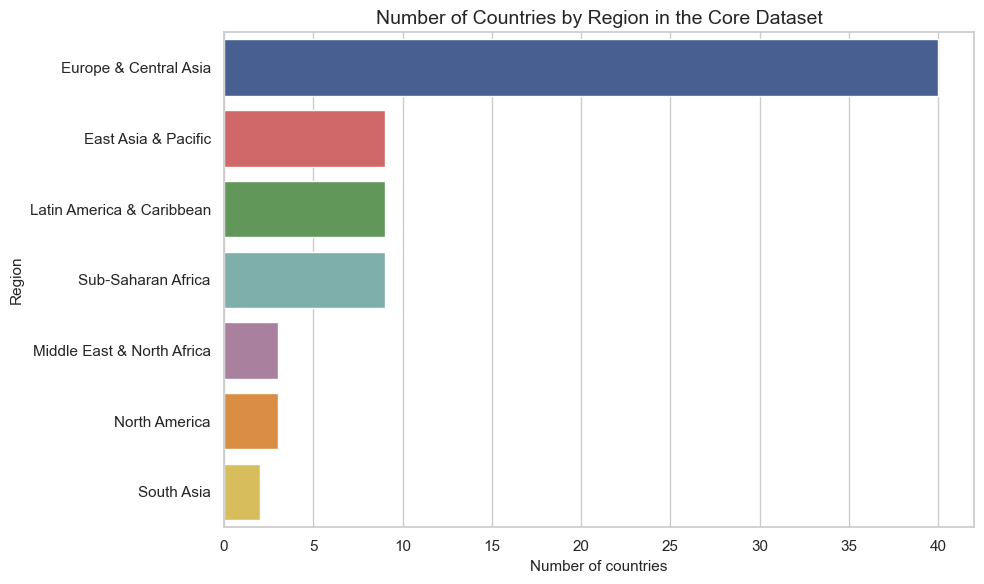

In [24]:
region_coverage = (
    df_core
    .drop_duplicates(subset=["iso3", "region"])
    .groupby("region")["iso3"]
    .nunique()
    .sort_values(ascending=False)
)

print(region_coverage)

plt.figure()
sns.barplot(
    x=region_coverage.values,
    y=region_coverage.index,
    palette=[region_colors.get(region, "#333333") for region in region_coverage.index]
)

plt.title("Number of Countries by Region in the Core Dataset")
plt.xlabel("Number of countries")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

### 3. GHG EMISSIONS BY REGION

This boxplot compares **emissions across regions**. The boxplot is useful because it does not only show the mean, but also:

- central values;
- dispersion;
- extreme countries.

It highlights the **internal variability** within regions.

This boxplot shows that GHG emissions per capita vary strongly across regions, both in terms of typical values and internal dispersion. **North America** has the highest median emissions, meaning that the typical country in this region has relatively high emissions per person. **East Asia & Pacific** also shows high emissions, but with a much wider spread and a very high outlier, suggesting strong differences between countries within the same region. **Europe & Central Asia** has a more moderate median, but some outliers indicate that a few countries emit substantially more than the regional norm.

On the other hand, **South Asia** and **Sub-Saharan Africa** show much lower median emissions, meaning that per-capita emissions are generally lower in these regions. However, Sub-Saharan Africa still presents some variation and an outlier, while South Asia appears more compact and homogeneous. Overall, the graph shows that regional climate profiles are not uniform: a simple average would hide important within-region differences, especially in regions such as East Asia & Pacific, where emissions are highly unequal across countries.


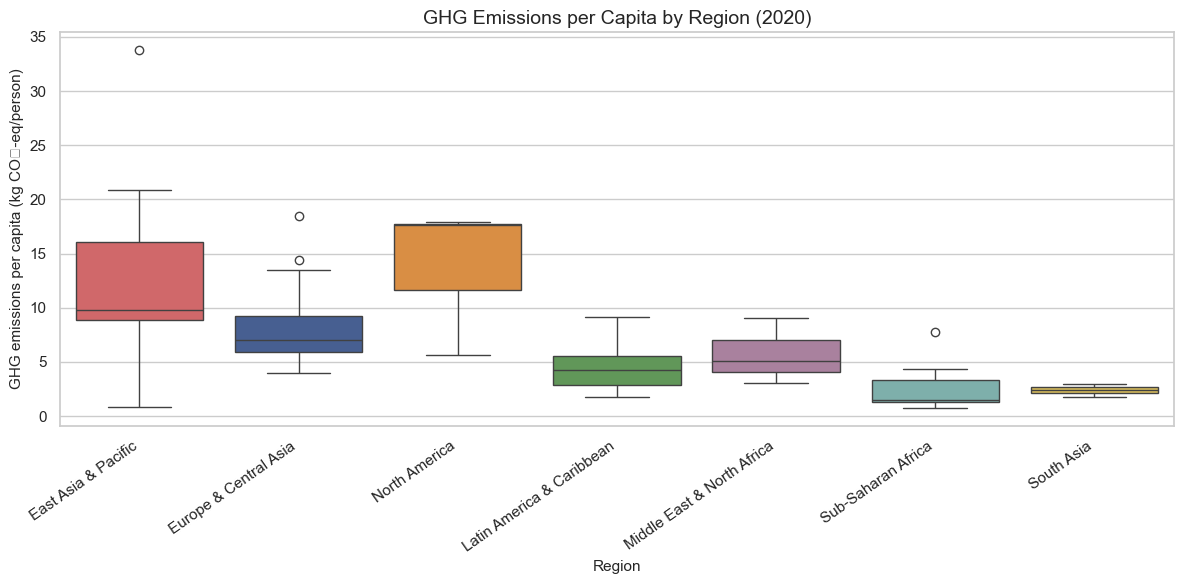

In [25]:
latest_core_year = df_core["year"].max()
latest_core = df_core[df_core["year"] == latest_core_year].copy()
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=latest_core,
    x="region",
    y="ghg_per_capita",
    palette=region_colors
)

plt.title(f"GHG Emissions per Capita by Region ({latest_core_year})")
plt.xlabel("Region")
plt.ylabel("GHG emissions per capita (kg CO₂-eq/person)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### 4. GDP PER CAPITA VS GHG EMISSIONS


This graph shows that richer countries usually have higher GHG emissions per person. Countries in the **bottom-left**, such as **Ghana, Kenya, and Guinea-Bissau**, have both low GDP per capita and low emissions. Countries in the **upper-right**, such as **USA, Canada, Australia, and Brunei**, have high GDP per capita and high emissions. However, the relationship is not perfect: for example, **Singapore** is very rich but has lower emissions than the USA or Brunei, showing that emissions also depend on energy sources, technology, and economic structure.

The x-axis uses a **log scale**, so distances are not read like a normal axis. Moving from 10,000 to 100,000 does not mean adding the same amount each time; it means multiplying income by 10. This is useful because GDP per capita varies a lot across countries. The log scale makes poorer and middle-income countries easier to see instead of compressing them all on the left side. Overall, the graph suggests that wealth is generally linked to higher emissions, but countries with similar income can still pollute very differently.


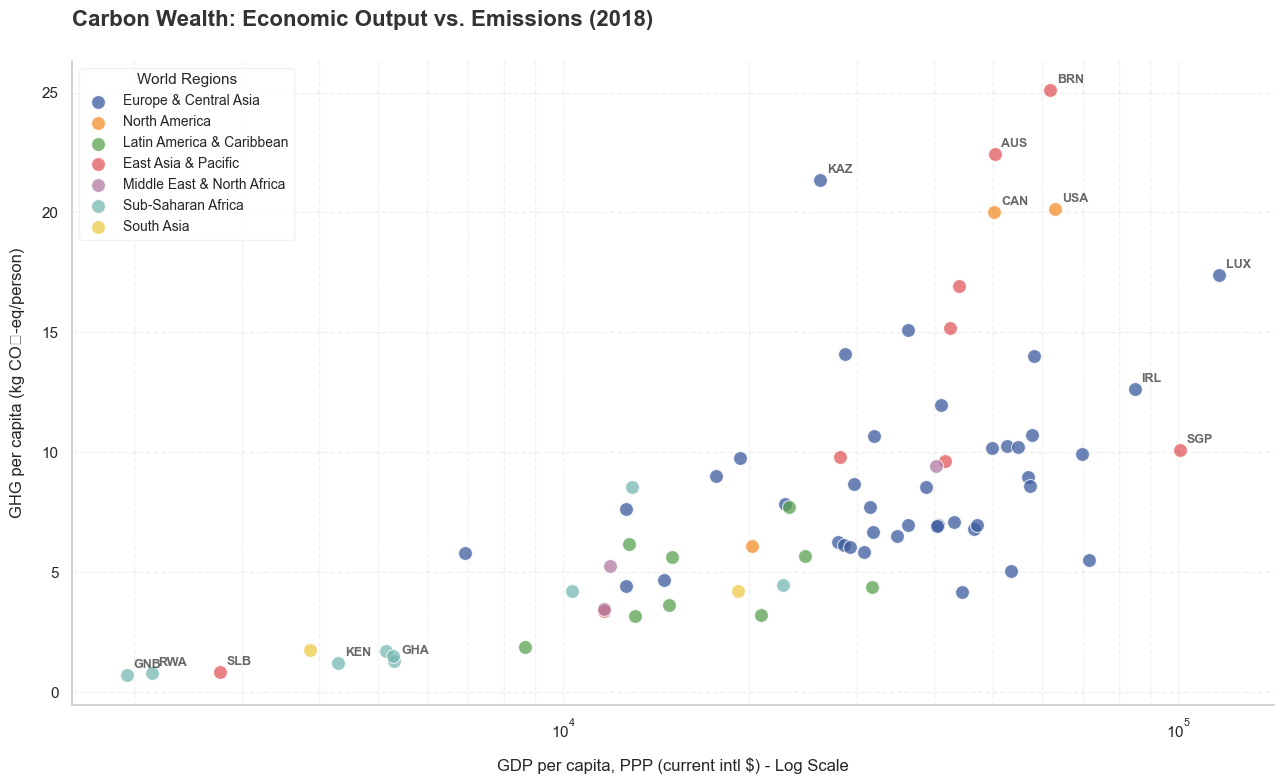

In [26]:
df_core = pd.read_csv('df_core.csv')
data_2018 = df_core[df_core['year'] == 2018].copy()

fig, ax = plt.subplots(figsize=(13, 8), facecolor='white')

for region, color in region_colors.items():
    sub = data_2018[data_2018['region'] == region]
    if not sub.empty:
        ax.scatter(
            sub['gdp_per_capita_ppp'], 
            sub['ghg_per_capita'],
            c=color, 
            label=region, 
            alpha=0.75, 
            s=100,             
            edgecolors='white', 
            linewidths=0.8, 
            zorder=3
        )

# 2. Scala Logaritmica (Rende la distribuzione molto più leggibile)
ax.set_xscale('log')

# 3. Annotazione Outlier (Top/Bottom emitters + Top Wealth)
top5 = data_2018.nlargest(5, 'ghg_per_capita')
bot5 = data_2018.nsmallest(5, 'ghg_per_capita')
rich = data_2018.nlargest(3, 'gdp_per_capita_ppp')
annots = pd.concat([top5, bot5, rich]).drop_duplicates()

for _, row in annots.iterrows():
    ax.annotate(
        row['iso3'], 
        (row['gdp_per_capita_ppp'], row['ghg_per_capita']),
        fontsize=9, 
        fontweight='bold', 
        alpha=0.7,
        xytext=(5, 5), 
        textcoords='offset points'
    )

# 4. Estetica e Labels
ax.set_xlabel('GDP per capita, PPP (current intl $) - Log Scale', fontsize=12, labelpad=12)
ax.set_ylabel('GHG per capita (kg CO₂-eq/person)', fontsize=12, labelpad=12)
ax.set_title('Carbon Wealth: Economic Output vs. Emissions (2018)', 
             fontsize=16, pad=25, loc='left', fontweight='bold', color='#333333')

# Griglia e bordi
ax.grid(True, which="both", linestyle='--', alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Legenda esterna o pulita
ax.legend(title="World Regions", title_fontsize=11, fontsize=10, 
          frameon=True, facecolor='white', edgecolor='#eeeeee', loc='upper left')

plt.tight_layout()
plt.show()

### 5. RENEWABLE ENERGY SHARE VS GHG EMISSIONS


This graph shows a **negative relationship** between renewable energy share and GHG emissions per capita: in general, countries that use more renewable energy tend to emit less. For example, countries on the **right side** (high renewable share, like **Norway (NOR)** or **Rwanda (RWA)**) have **very low emissions**, while countries on the **left side** (low renewable share, like **USA, Canada, or Australia (AUS)**) tend to have **high emissions**. This suggests that increasing renewable energy is associated with lower pollution.

However, the relationship is not perfect. Some countries with **low renewable energy still have medium emissions** (many in **Europe & Central Asia**), and a few countries with **moderate renewable share still emit a lot** (like **Kazakhstan (KAZ)** or **Australia (AUS)**). This means that the relationship is shaped by other factors too, including industrial structure, total energy demand, energy efficiency, hydro endowments, and the fact that the World Bank renewable measure can include **traditional biomass** in lower-income countries. A safer conclusion is that renewable share is a useful contextual variable, but it does not by itself explain cross-country emissions differences.

Overall, the graph shows that renewables help reduce emissions, but they are **not the only factor**.


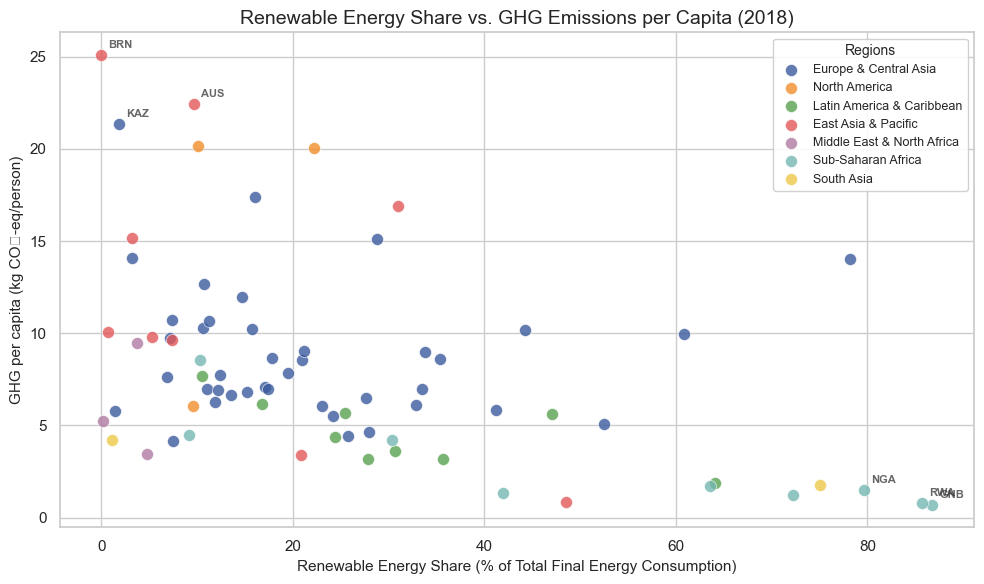

In [27]:
# Filter for year 2018 (consistent with previous analysis and good data coverage)
data_plot = df_core[df_core['year'] == 2018].copy()

# Drop missing values for the relevant variables to ensure a clean plot
data_plot = data_plot.dropna(subset=['renewable_pct', 'ghg_per_capita'])

fig, ax = plt.subplots()

# Create the scatter plot by region
for region, color in region_colors.items():
    sub = data_plot[data_plot['region'] == region]
    if not sub.empty:
        ax.scatter(
            sub['renewable_pct'], 
            sub['ghg_per_capita'],
            c=color, 
            label=region, 
            alpha=0.8, 
            s=75, 
            edgecolors='white', 
            linewidths=0.5,
            zorder=3
        )

# Annotate outliers (Top 3 by renewable share and Top 3 by emissions)
top_renew = data_plot.nlargest(3, 'renewable_pct')
top_emit = data_plot.nlargest(3, 'ghg_per_capita')
annots = pd.concat([top_renew, top_emit]).drop_duplicates()

for _, row in annots.iterrows():
    ax.annotate(
        row['iso3'], 
        (row['renewable_pct'], row['ghg_per_capita']),
        fontsize=8, 
        xytext=(5, 5), 
        textcoords='offset points',
        fontweight='bold',
        alpha=0.7
    )

ax.set_xlabel('Renewable Energy Share (% of Total Final Energy Consumption)')
ax.set_ylabel('GHG per capita (kg CO₂-eq/person)')
ax.set_title('Renewable Energy Share vs. GHG Emissions per Capita (2018)')

ax.legend(title="Regions", fontsize=9, title_fontsize=10, framealpha=0.9, loc='upper right')

plt.tight_layout()
plt.show()

### 6. AVERAGE GHG TREND OVER TIME BY REGION

This graph shows how average GHG emissions per capita evolved across regions from 2014 to 2023. **North America** remains the highest emitter throughout the period, slightly declining until 2020 and then increasing again sharply by 2023. **East Asia & Pacific** follows a similar pattern: a gradual decrease until around 2020, then a strong rebound, reaching higher levels again by 2023. In contrast, **Europe & Central Asia** shows a more stable and slightly decreasing trend over time, suggesting some gradual improvement in reducing emissions.

Other regions behave differently. **Latin America & Caribbean** shows a slow but steady increase in emissions over time. **Middle East & North Africa** is much more volatile, with a sharp spike around 2019, a drop in 2020, and then another increase by 2023. Meanwhile, **Sub-Saharan Africa** and **South Asia** remain consistently low throughout the period, with only small fluctuations. 

However, this chart should be interpreted **carefully at the end of the series**. Country coverage falls substantially by 2023, and some regions are represented by far fewer countries than in earlier years. This means late-year regional averages reflect **both real emissions change and changing sample composition**. The figure is still useful descriptively, but it should not be treated as a like-for-like balanced-panel trend unless the country set is fixed across all years.

Overall, the graph highlights that while some regions have reduced emissions temporarily, many experienced a rebound after 2020, suggesting that long-term reduction trends are still unstable.


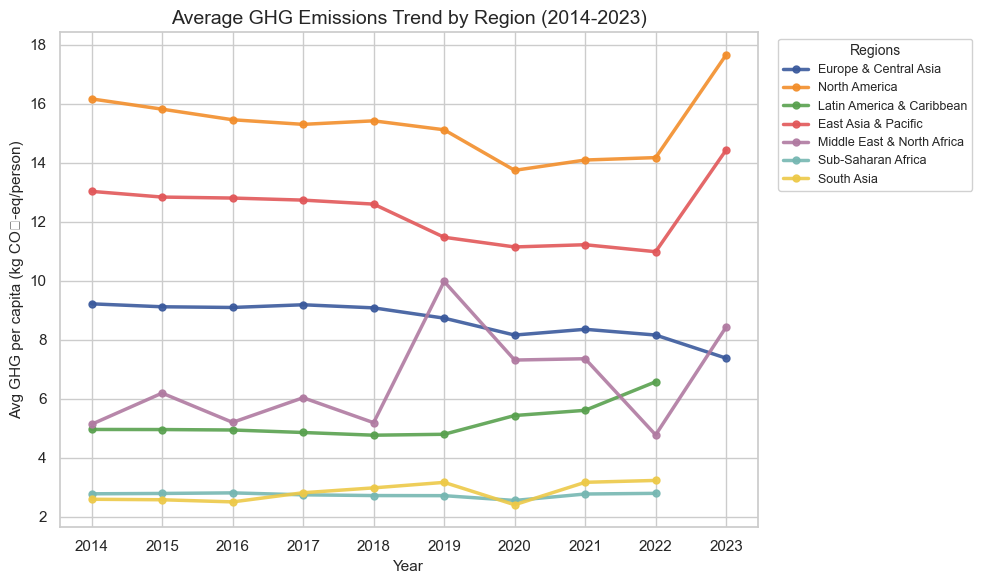

In [28]:
# Preprocess data: calculate mean GHG per capita by year and region
trend_region = (
    df_trend
    .dropna(subset=["region", "ghg_per_capita"])
    .groupby(["year", "region"], as_index=False)["ghg_per_capita"]
    .mean()
)

# Ensure data is sorted by year for correct line plotting
trend_region = trend_region.sort_values("year")


fig, ax = plt.subplots()

# Plot trend line for each region using the defined palette
for region, color in region_colors.items():
    region_data = trend_region[trend_region['region'] == region]
    if not region_data.empty:
        ax.plot(
            region_data['year'], 
            region_data['ghg_per_capita'], 
            marker='o', 
            markersize=5, 
            label=region, 
            color=color, 
            linewidth=2.5, 
            alpha=0.9
        )

# Axis labels and Title in English
ax.set_xlabel('Year')
ax.set_ylabel('Avg GHG per capita (kg CO₂-eq/person)')
ax.set_title('Average GHG Emissions Trend by Region (2014-2023)')

# Ensure the x-axis displays years as integers
ax.set_xticks(trend_region['year'].unique())

# Place the legend outside the plot for better clarity
ax.legend(title="Regions", fontsize=9, title_fontsize=10, framealpha=0.9, 
          bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [29]:
# Diagnostic: show how many countries contribute to each regional average by year
trend_region_counts = (
    df_trend
    .dropna(subset=["region", "ghg_per_capita"])
    .groupby(["year", "region"])["iso3"]
    .nunique()
    .unstack(fill_value=0)
)

print('Countries contributing to each region-year average:')
print(trend_region_counts)

print('\nTotal countries by year:')
print(df_trend.groupby('year')['iso3'].nunique())


Countries contributing to each region-year average:
region  East Asia & Pacific  Europe & Central Asia  Latin America & Caribbean  \
year                                                                            
2014                      9                     43                         11   
2015                      9                     43                         11   
2016                      9                     43                         11   
2017                      9                     43                         11   
2018                      9                     43                         11   
2019                     10                     43                         11   
2020                     12                     44                         12   
2021                     12                     44                         12   
2022                     10                     44                          8   
2023                      3                     39       

### 7. LARGEST EMISSION REDUCTIONS AND INCREASES

This figure compares countries with the **largest decreases** and **largest increases** in GHG emissions per capita between 2014 and 2023.

It is useful for highlighting directional change, but it does **not** cover the full GHG sample. Only countries with observations in **both endpoint years** appear here, so the chart reflects a reduced subset rather than all countries in `df_trend`. For that reason, it is best framed as an **endpoint comparison among countries with complete endpoints**, not a definitive ranking of all countries in the database.

On the left, countries like **Estonia, Luxembourg, and Malta** show very strong reductions (up to around −50%), followed by others such as **Finland, the UK, and Germany**, which also achieved substantial declines. This suggests that several European countries have been relatively successful in reducing emissions, likely due to energy transition policies, efficiency improvements, and stricter environmental regulations.

On the right, we see countries with the largest increases. **Serbia, Türkiye, and Croatia** show the biggest growth in emissions, while others like **Russia** also increased but more moderately. Some countries (like **Romania or Cyprus**) even appear slightly negative, meaning small reductions rather than increases. Overall, the graph highlights a **divergence across countries**: while some are making strong progress in cutting emissions, others are still moving in the opposite direction, showing that climate performance is highly uneven even within similar regions.


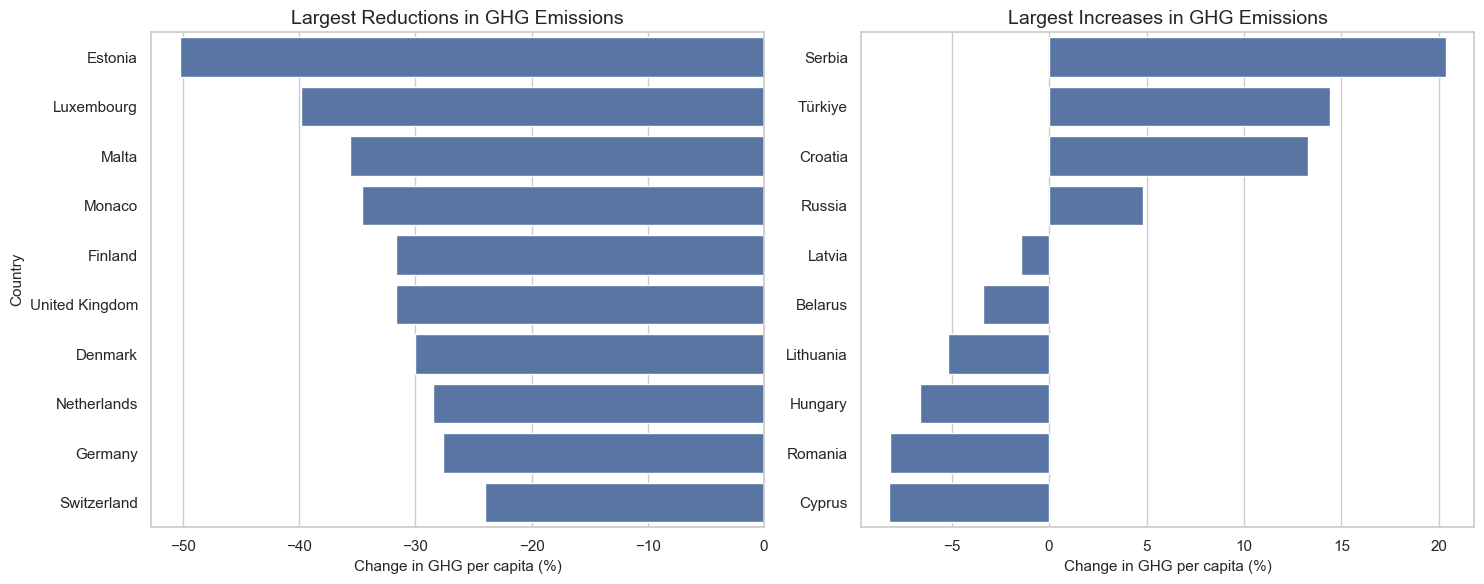

In [30]:
slope_clean = df_slope.dropna(subset=["ghg_change_pct"]).copy()

largest_reductions = slope_clean.nsmallest(10, "ghg_change_pct")
largest_increases = slope_clean.nlargest(10, "ghg_change_pct")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=largest_reductions,
    x="ghg_change_pct",
    y="country_name_ghg",
    ax=axes[0]
)
axes[0].set_title("Largest Reductions in GHG Emissions")
axes[0].set_xlabel("Change in GHG per capita (%)")
axes[0].set_ylabel("Country")

sns.barplot(
    data=largest_increases,
    x="ghg_change_pct",
    y="country_name_ghg",
    ax=axes[1]
)
axes[1].set_title("Largest Increases in GHG Emissions")
axes[1].set_xlabel("Change in GHG per capita (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 8. CORRELATION MATRIX

The main insight is that **wealth is strongly linked to emissions**. GHG emissions per capita have a **high positive correlation with GDP per capita (0.62)** and even more with **log GDP (0.65)**. This confirms what we saw in the scatter plots: richer countries tend to emit more. At the same time, GDP is also strongly correlated with **electricity access (0.45 and 0.73 with log GDP)**, meaning richer countries are more developed and have better infrastructure, which is associated with higher energy use and emissions.

Another key result is the role of energy composition. **Renewable energy share is negatively correlated with emissions (−0.45)**, meaning more renewables are associated with lower emissions. It is also strongly **negatively correlated with fossil fuel use (−0.84)**, which makes sense since they are substitutes. Additionally, renewables are negatively related to GDP (−0.32), suggesting that richer countries do not necessarily rely more on renewables. 

The fossil-fuel result should be treated more cautiously than the other correlations. `fossil_fuel_pct` has much weaker coverage than the main variables, so its correlations are estimated on a smaller effective subset. That makes it useful as supporting context, but not strong enough to anchor the headline interpretation.

Overall, emissions are driven by both **economic development (positive effect)** and **energy mix (renewables reduce emissions, fossil fuels increase them)**.


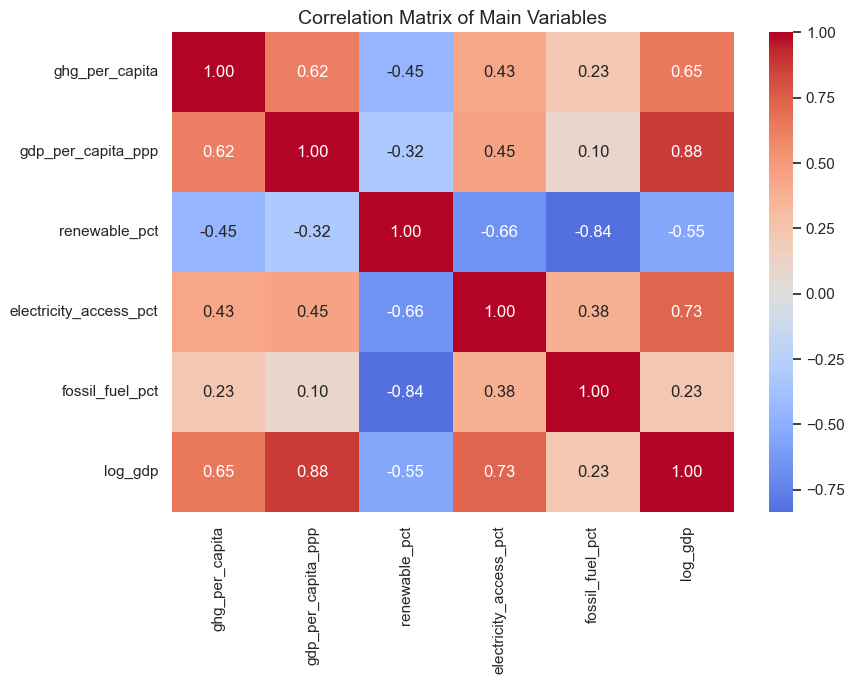

In [31]:
numeric_columns = [
    "ghg_per_capita",
    "gdp_per_capita_ppp",
    "renewable_pct",
    "electricity_access_pct",
    "fossil_fuel_pct",
    "log_gdp"
]

corr_data = df_core[numeric_columns].dropna(how="all")
corr_matrix = corr_data.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Main Variables")
plt.tight_layout()
plt.show()

In [32]:
# Diagnostic: variable coverage behind the correlation matrix
coverage = df_core[['ghg_per_capita', 'gdp_per_capita_ppp', 'renewable_pct', 'electricity_access_pct', 'fossil_fuel_pct', 'log_gdp']].notna().sum()
print('Non-missing observations per variable in df_core:')
print(coverage)

print('\nShare of non-missing observations (%):')
print((coverage / len(df_core) * 100).round(1))


Non-missing observations per variable in df_core:
ghg_per_capita            525
gdp_per_capita_ppp        524
renewable_pct             375
electricity_access_pct    450
fossil_fuel_pct           103
log_gdp                   524
dtype: int64

Share of non-missing observations (%):
ghg_per_capita           100.00
gdp_per_capita_ppp        99.80
renewable_pct             71.40
electricity_access_pct    85.70
fossil_fuel_pct           19.60
log_gdp                   99.80
dtype: float64


## 12. Limitations & Bias Summary

| Issue | Detail | Impact on Analysis |
|-------|--------|--------------------|
| **Temporal mismatch** | World Bank data ends at 2020; OECD GHG runs to 2023. The full 3-dataset panel is limited to 2014–2020. | Trend visualizations use GHG alone (2014–2023); wealth and energy visualizations are limited to 2014–2020. |
| **Core sample is partially balanced** | The analytical sample keeps countries with **>=5 complete years** rather than all 7 years. | This preserves coverage but weakens strict comparability across time and across linked visualizations. |
| **Late-period GHG coverage drops** | The GHG-only dataset has much thinner coverage by 2023 than in earlier years. | Regional averages and endpoint comparisons may reflect changing sample composition as well as real emissions change. |
| **Geographic coverage** | The joined panel includes about **90 countries**, while the core sample includes **75 countries**. Sub-Saharan Africa and small states remain underrepresented. | Core findings should not be generalized too confidently to the Global South as a whole. |
| **LULUCF exclusion** | OECD GHG data excludes Land Use, Land Use Change and Forestry emissions by design (`MEASURE = '_T'`). | Net emissions of countries with heavy deforestation may be underestimated. |
| **Region variable constructed** | The `region` column is manually mapped from World Bank country metadata rather than taken directly from the raw files. | Any mapping error would propagate to all regional summaries. |
| **Renewable energy definition** | World Bank `renewable_pct` includes traditional biomass, which can reflect energy poverty rather than clean transition. | Some low-income countries may appear renewable-heavy for the wrong reason, distorting classifications such as `green_by_choice_flag`. |
| **Correlation != causation** | The project identifies empirical patterns only; no causal model is estimated. | Findings must be framed as associations rather than effects. |
| **PPP vs nominal GDP** | GDP per capita PPP is measured in **current** international dollars, so year-to-year changes still embed inflation and price-level shifts. | Intertemporal GDP comparisons partly reflect nominal movement, not just real growth. |


## 13. Visualization-Dataset Mapping (FINALE IN TEORIA)


| # | Final visualization                               | Type                              | Tool                             | Dataset                                 | Why it should be included                                                                                                                                  |
| - | ------------------------------------------------- | --------------------------------- | -------------------------------- | --------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1 | Interactive world map of GHG emissions per capita | Interactive / linked              | Power BI                         | `df_panel.csv`                          | Best opening view: it gives geographic context and can work as the main filtering hub by country, region, and year.                                        |
| 2 | Wealth vs emissions scatterplot                   | Interactive / linked              | Power BI                         | `df_core.csv` or `df_panel.csv`         | Strong analytical view: it connects economic development with climate responsibility and reveals outliers.                                                 |
| 3 | Green by choice vs energy poverty quadrant chart  | Interactive / linked              | Power BI                         | `df_core.csv`                           | This should be a core view because it directly answers your main interpretive question: low emissions can mean sustainability or lack of access.           |
| 4 | Regional boxplot of GHG emissions                 | Interactive or static exploratory | Python / Plotly                  | `df_core.csv`                           | Better than a simple bar chart because it shows regional inequality, dispersion, and outliers.                                                             |
| 5 | Slope chart of emission change                    | Interactive or static             | Python / Plotly                  | `df_slope.csv`                          | Adds the time/change dimension and shows which countries improved or worsened from the initial to final year.                                              |
| 6 | Country profile explanatory card                  | Explanatory / non-expert / JS     | JavaScript embedded in WordPress | `df_core.csv` + optional `df_trend.csv` | Required-style non-expert view: it translates indicators into an easy country-level explanation. Also satisfies the JavaScript feature.                    |
| 7 | Creative emissions-energy ladder                  | Creative visualization            | JavaScript / D3.js               | `df_core.csv`                           | Best creative option because it visually communicates the project’s central idea: countries move from energy poverty to sustainable low-emission profiles. |
| 8 | White-hat / black-hat comparison                  | Two static ethical views          | Python                           | `df_core.csv`                           | Required by the guidelines. The white-hat version gives a fair contextual reading; the black-hat version shows how the same data can mislead.              |


## MAIN DIFFERENCES BETWEEN THE VISUALIZATION

| Final visualization kept                       | From MARTA’s block                                                | From second block                                 | Main difference                                                                                                                                                                                                                                                                                                               |
| ---------------------------------------------- | ----------------------------------------------------------------- | ------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1. Interactive world map                       | Choropleth map using `df_panel.csv` in Power BI                   | Interactive world map of GHG emissions per capita | They are almost the same. MARTA’s version is more precise about variables and cross-filtering; the second block explains better why the map helps non-expert users understand geographic patterns.                                                                                                                            |
| 2. Wealth vs emissions scatterplot             | Bubble scatter GDP vs GHG in Power BI                             | Wealth vs emissions scatterplot                   | Same core idea. MARTA’s version emphasizes outliers and year-by-year interaction; the second block frames it more clearly as a relationship between economic development and climate responsibility.                                                                                                                          |
| 3. Green by choice vs energy poverty quadrant  | Scatter electricity access vs GHG                                 | Green by choice vs energy poverty quadrant chart  | This is stronger in the second block. MARTA’s version is a simple scatterplot; the second block turns it into a clear interpretive quadrant with categories, making it more central to the research question.                                                                                                                 |
| 4. Regional boxplot                            | Not explicitly in MARTA’s block                                   | Regional boxplot of GHG emissions                 | This comes from the second block. It adds distributional analysis by region, which MARTA’s list was missing. It is useful because it shows inequality inside regions, not only average differences.                                                                                                                           |
| 5. Slope chart of emission change              | Slope chart 2014→2023 using `df_slope.csv`                        | Slope chart of emission change                    | Same idea. MARTA’s version is more precise about the input file and variables; the second block gives a simpler design rationale: it shows improvement or deterioration over time.                                                                                                                                            |
| 6. Country profile explanatory card            | Country profile card in JavaScript                                | Country profile explanatory card                  | Very similar. MARTA’s version emphasizes comparison with regional and global averages; the second block better highlights its role as an explanatory view for non-expert users.                                                                                                                                               |
| 7. Creative emissions-energy ladder            | Not present directly; closest idea is radial emission fingerprint | Creative emissions-energy ladder                  | This mainly comes from the second block. MARTA proposed a radial fingerprint, but the ladder is clearer, more memorable, and better connected to the project’s central message about sustainability vs energy poverty.                                                                                                        |
| 8. White-hat / black-hat static visualizations | White hat / Black hat maps                                        | White-hat and black-hat static visualization      | Both blocks include this requirement, but differently. MARTA suggests maps comparing per-capita vs absolute emissions. The second block suggests an ethical contrast between a contextualized white-hat view and a misleading black-hat ranking. The second version is probably stronger for the report’s ethical reflection. |


## IDEE MIE

| # | Visualization idea | Dataset | Research question answered | What it represents | Design logic | Suggested tool |
|---|---|---|---|---|---|---|
| 1 | Interactive world map of GHG emissions per capita | `df_panel.csv` | Which countries emit the most greenhouse gases per person, and how does this change across years? | A choropleth map where countries are colored by GHG emissions per capita, with filters for year and region. | The map gives an immediate geographic overview and helps non-expert users understand where emissions are concentrated. Tooltip details should reduce the risk of misleading interpretation caused by country size. | Power BI or Tableau |
| 2 | Wealth vs emissions scatterplot | `df_core.csv` | Are richer countries also higher emitters per person? | Each point is a country. X-axis shows GDP per capita PPP, Y-axis shows GHG emissions per capita, color shows region, and size can show renewable share or electricity access. | This view connects economic development with climate responsibility and helps identify rich high-emission countries as well as lower-income low-emission countries. | Tableau or Power BI |
| 3 | Green by choice vs energy poverty quadrant chart | `df_core.csv` | Are low-emission countries actually sustainable, or do they emit less because of limited energy access? | A scatterplot using electricity access and GHG emissions, with countries classified using `energy_poverty_flag` and `green_by_choice_flag`. | This is the core interpretive view: it prevents the misleading conclusion that all low-emission countries are automatically sustainable. | Power BI, Tableau, or JavaScript |
| 4 | Regional boxplot of GHG emissions | `df_core.csv` | Do regions differ only in average emissions, or also in internal inequality? | A boxplot showing the distribution of GHG emissions per capita within each region. | The boxplot shows median, spread, and outliers, making it more informative than a simple bar chart of regional averages. | Python or Tableau |
| 5 | Slope chart of emission change | `df_slope.csv` | Which countries reduced or increased their emissions the most over time? | A slope chart comparing each country’s initial and final GHG emissions per capita. | This view focuses on change over time rather than only current levels, helping identify improvement or deterioration. | Tableau or Python |
| 6 | Regional trend with highlighted moments | `df_trend.csv` | Are regional emission patterns converging, diverging, or remaining stable over time? | A time-based view showing average GHG emissions per capita by region from 2014 to 2023. | The trend view adds a temporal dimension and can be improved with small multiples, sparklines, or highlighted years to avoid a basic line chart. | Tableau, Power BI, or Python |
| 7 | Country profile explanatory card | `df_core.csv` + optional `df_trend.csv` | What does a country’s climate-energy profile mean in simple terms? | A selected country card showing GHG emissions, GDP, renewable share, electricity access, and an interpretive category. | This is designed for non-expert users because it translates numeric indicators into a short explanation. | JavaScript embedded in WordPress |
| 8 | Creative “emissions-energy ladder” | `df_core.csv` | Which countries are low emitters because they are sustainable, and which are low emitters because they are energy constrained? | A creative visual metaphor positioning countries along a ladder from energy poverty to sustainable low-emission profiles. | The metaphor makes the project’s central message memorable and satisfies the requirement for a creative visualization. | JavaScript/D3.js or Python static prototype |
| 9 | White-hat static visualization | `df_core.csv` | How can we communicate climate responsibility without hiding energy inequality? | A transparent static visual showing emissions together with electricity access and renewable share. | The white-hat version presents a fair interpretation by including context, limitations, and clear thresholds. | Python |
| 10 | Black-hat static visualization | `df_core.csv` | How could the same data be used misleadingly? | A misleading bar chart ranking low-emission countries as “green leaders” without showing energy access or GDP. | The black-hat version demonstrates how true data can still produce a biased or manipulative message when context is removed. | Python |

## MARTA IDEE

The table below documents which cleaned output file feeds each visualization, to ensure reproducibility and make the Power BI / Python / JS development steps self-contained.

| Viz | Title | Tool | Input file | Key variables | Analytical question |
|-----|-------|------|------------|---------------|---------------------|
| 01 | Choropleth map | Power BI | `df_panel.csv` | `iso3`, `year`, `ghg_per_capita`, `region` | Where are emissions highest, and how has the global distribution shifted year by year from 2014 to 2020? Serves as the spatial entry point and cross-filtering hub for the whole dashboard. |
| 02 | Bubble scatter GDP vs GHG | Power BI | `df_panel.csv` | `gdp_per_capita_ppp`, `ghg_per_capita`, `region`, `year` | Do wealthier countries systematically emit more per capita? Which countries break the expected pattern, that is high income but low emissions, or low income but high emissions? |
| 03 | Slope chart 2014→2023 | Python (Plotly) | `df_slope.csv` | `ghg_2014`, `ghg_2023`, `ghg_change_pct`, `region` | Which countries have reduced their per-capita emissions the most over the decade, and which have worsened? Does improvement cluster by region or income level? |
| 04 | Diverging dot plot GHG vs renewables | Python (Altair) | `df_core.csv` | `ghg_per_capita`, `renewable_pct`, `region` | Is there a clean inverse relationship between renewable energy share and emissions? Do low-emission countries tend to have high renewables, or are other factors at play? |
| 05 | Country profile card | JavaScript | `df_core.csv` | all key variables, `country_name_ghg` | How does any single country compare to its regional and global averages across all four key dimensions simultaneously? Supports the deep-profile task for non-expert users. |
| 06 | Scatter electricity access vs GHG | Power BI | `df_panel.csv` | `electricity_access_pct`, `ghg_per_capita`, `region` | Are low-emission countries truly "clean", or are their low figures explained by limited electricity access and energy poverty rather than deliberate decarbonization? |
| 07 ★ | Radial Emission Fingerprint | D3.js | `df_core.csv` | `ghg_per_capita`, `gdp_per_capita_ppp`, `renewable_pct`, `electricity_access_pct` | What is the full four-variable "emissions profile" of a country, and how do up to four countries compare when all dimensions are shown simultaneously on a single radial form? |
| 08 | White hat / Black hat maps | Power BI | `df_panel.csv` | `iso3`, `ghg_per_capita` (per capita vs absolute) | How does the choice of metric, per capita vs total absolute emissions, produce opposite narratives from the same data, making small rich countries appear as villains or heroes depending on framing? |